# Muffin vs Chihuahua Image Classification

This project was inspired by the popular "Muffin vs Chihuahua" internet meme, which highlights how visually similar certain muffins and Chihuahuas can appear. The meme presents a fun image classification challenge that demonstrates the capabilities of Convolutional Neural Networks (CNNs) and Transfer Learning for computer vision tasks:

<img src="images/blueberrychihuahuacaptcha.png" width="30%">

## 0. Introduction

### Project Objective

Image classification is one of the most common applications of deep learning and computer vision. Convolutional Neural Networks (CNNs) are particularly effective at identifying visual patterns and classifying images into predefined categories.

In this project, a CNN is developed to classify images into one of two categories:

* Chihuahua
* Muffin

The project follows a complete deep learning workflow, including data preparation, model development, training, evaluation, model improvement, and deployment of the final model as an interactive web application.

The final model will also be saved and deployed as an interactive demo that allows users to upload their own images and test the classifier.

### Research Question

Can a Convolutional Neural Network accurately distinguish between images of chihuahuas and muffins?

### Expected Outcome

The expectation is that the CNN will learn meaningful visual features from the training images and achieve strong classification performance on new, unseen data. Model performance will be evaluated using accuracy, a confusion matrix, a classification report, and an analysis of misclassified images.

## 1. Imports

In [1]:
# ============================================================
# 1. Libraries
# ============================================================

# Data handling
import numpy as np
import pandas as pd
import random
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image handling
from PIL import Image

# Deep Learning
import tensorflow as tf

# Models
from tensorflow.keras import Input
from tensorflow.keras.models import (
    Sequential,
    Model,
    load_model
)

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping

# Transfer Learning
from tensorflow.keras.applications import MobileNetV2

# Layers
from keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

# Image Preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

# ============================================================
# TensorFlow Version
# ============================================================

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


## 2. Dataset & Overview

### 2.1 Dataset Description

This project uses the **Muffin vs Chihuahua** image classification dataset from Kaggle: https://www.kaggle.com/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification

The dataset consists of images of muffins and chihuahua dogs collected from Google Images. Duplicate images were removed by the dataset creator to improve data quality.

This is a **binary image classification problem**, where each image belongs to one of two classes:

* Chihuahua
* Muffin

The dataset was selected because it contains two categories that can appear visually similar in certain images, making the classification task more challenging than traditional image classification datasets.

### 2.2 Dataset Distribution

| Class     | Training Images | Test Images |
| --------- | --------------: | ----------: |
| Chihuahua |           2,559 |         640 |
| Muffin    |           2,174 |         544 |
| **Total** |       **4,733** |   **1,184** |

Total number of images: **5,917**

The dataset is relatively balanced, with slightly more Chihuahua images than muffin images.

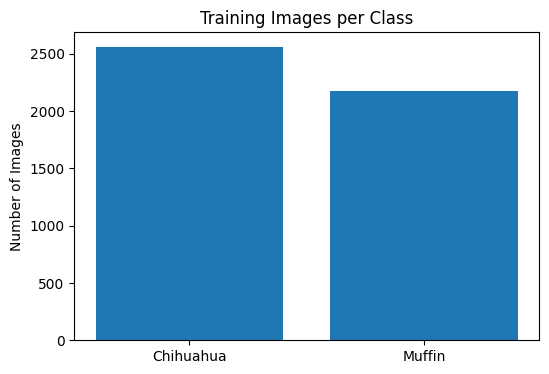

In [2]:
classes = ["Chihuahua", "Muffin"]
counts = [2559, 2174]

plt.figure(figsize=(6,4))
plt.bar(classes, counts)
plt.title("Training Images per Class")
plt.ylabel("Number of Images")
plt.show()

### 2.3 Sample Images

The following examples illustrate the two classes included in the dataset and provide an overview of the image variations present in the data.

In [3]:
train_dir = "train"
test_dir = "test"

chihuahua_dir = os.path.join(train_dir, "chihuahua")
muffin_dir = os.path.join(train_dir, "muffin")

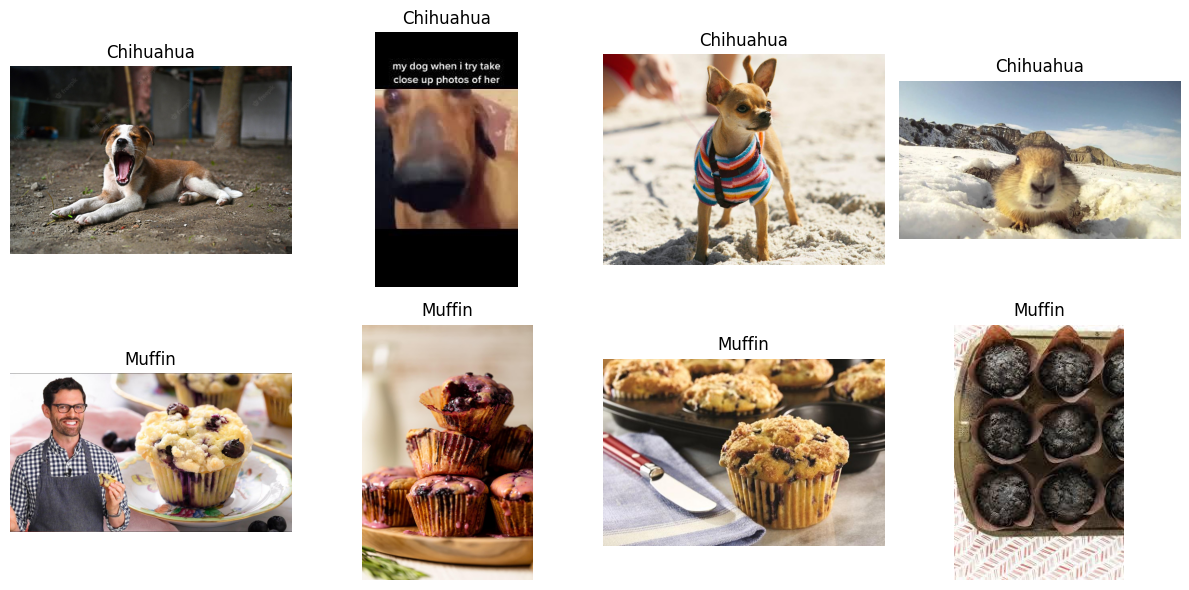

In [4]:
# Dataset paths
chihuahua_dir = "train/chihuahua"
muffin_dir = "train/muffin"

# Random images
chihuahua_images = random.sample(os.listdir(chihuahua_dir), 4)
muffin_images = random.sample(os.listdir(muffin_dir), 4)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Chihuahua row
for i, img_name in enumerate(chihuahua_images):
    img_path = os.path.join(chihuahua_dir, img_name)
    img = Image.open(img_path)

    axes[0, i].imshow(img)
    axes[0, i].set_title("Chihuahua")
    axes[0, i].axis("off")

# Muffin row
for i, img_name in enumerate(muffin_images):
    img_path = os.path.join(muffin_dir, img_name)
    img = Image.open(img_path)

    axes[1, i].imshow(img)
    axes[1, i].set_title("Muffin")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## 3. Data Preparation & Preprocessing

### 3.1 Overview

Before training the CNN, the images must be preprocessed to ensure a consistent format.

The preprocessing steps include:

- Resizing all images to a fixed size
- Normalizing pixel values

### 3.2 Define Image Parameters
All images will be resized to 128 × 128 pixels before being fed into the CNN. Using a fixed image size ensures that the neural network receives consistent input dimensions during training.

In [5]:
# Image settings
IMG_HEIGHT = 128
IMG_WIDTH = 128

BATCH_SIZE = 32

### 3.3 Image Normalization
Pixel values in RGB images range from 0 to 255.

To improve training performance and numerical stability, pixel values are normalized to the range 0–1 by dividing each pixel value by 255.

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

## 4. Build and Configure CNN Model

### 4.1 Create Training, Validation and Test Generators
The dataset is divided into training, validation, and test sets.

- Training data is used to train the CNN.
- Validation data is used to monitor model performance during training.
- Test data is used for final evaluation.



In [7]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 3788 images belonging to 2 classes.
Found 945 images belonging to 2 classes.
Found 1184 images belonging to 2 classes.


### 4.2 Verify Dataset Structure
The class labels generated by TensorFlow are verified before training.

In [8]:
print("Class labels:")
print(train_generator.class_indices)

print("Training samples:", train_generator.samples)
print("Validation samples:", validation_generator.samples)
print("Test samples:", test_generator.samples)

Class labels:
{'chihuahua': 0, 'muffin': 1}
Training samples: 3788
Validation samples: 945
Test samples: 1184


### 4.3 Build Baseline CNN Architecture
The CNN consists of two convolutional layers followed by max-pooling layers for feature extraction.

The extracted features are flattened and passed to fully connected layers for binary classification.

In [9]:
model = Sequential([

    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )

], name="Baseline_Muffin_Chihuahua_CNN")

### 4.4 Model Summary
The model summary provides an overview of the CNN architecture, output dimensions, and trainable parameters.

In [10]:
model.summary()

Model: "Baseline_Muffin_Chihuahua_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

### 4.5 Compile Model
The model is compiled using the Adam optimizer and binary cross-entropy loss function, which is appropriate for binary classification problems.

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 5. Train the Model

### 5.1 Train the Baseline CNN

In [12]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.6439 - loss: 0.6629 - val_accuracy: 0.8053 - val_loss: 0.4389
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.8218 - loss: 0.4128 - val_accuracy: 0.8508 - val_loss: 0.3474
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.8675 - loss: 0.3217 - val_accuracy: 0.8085 - val_loss: 0.4624
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.8944 - loss: 0.2535 - val_accuracy: 0.8762 - val_loss: 0.2934
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.9195 - loss: 0.2053 - val_accuracy: 0.8804 - val_loss: 0.2765
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.9480 - loss: 0.1463 - val_accuracy: 0.8772 - val_loss: 0.3167
Epoch 7/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.9691 - loss: 0.0868 - val_accuracy: 0.8836 - val_loss: 0.3234
Epoch 8/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.9876 - loss: 0.0434 - val_accu

### 5.2 Training Accuracy

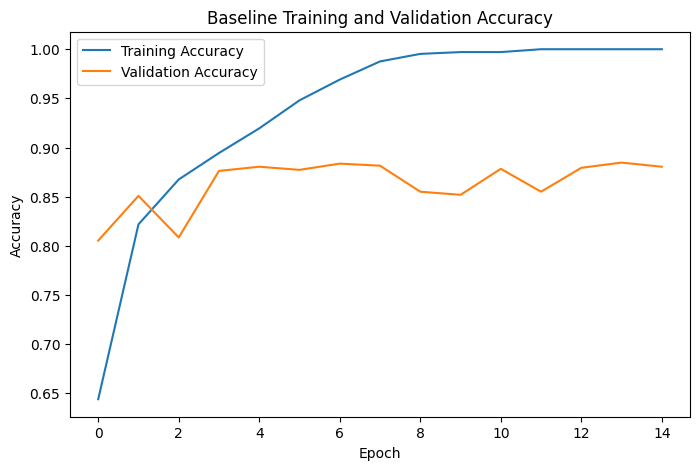

In [74]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Baseline Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### 5.3 Training Loss

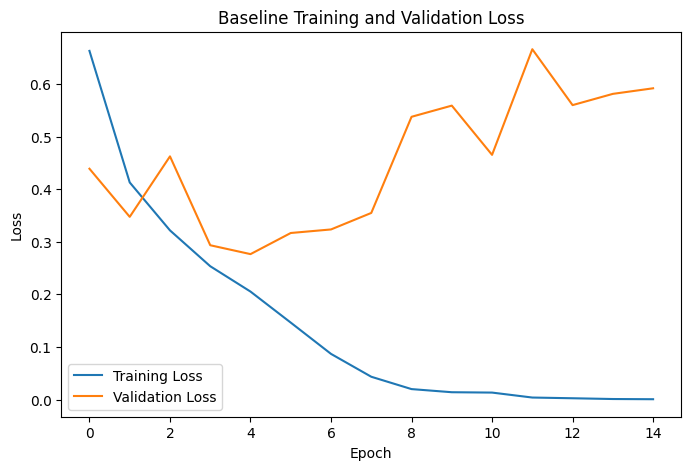

In [75]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Baseline Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### 5.4 Save Baseline Model
The trained baseline CNN is saved for later evaluation and comparison with improved models.

In [15]:
model.save(
    "muffin_chihuahua_baseline.keras"
)

print("Baseline model saved successfully.")

Baseline model saved successfully.


## 6. Evaluate the Model

### 6.1 Generate Predictions



In [16]:
test_generator.reset()

In [17]:
pred_probs = model.predict(test_generator)

predictions = (pred_probs > 0.5).astype(int).flatten()

true_labels = test_generator.classes

class_labels = list(
    test_generator.class_indices.keys()
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step


In [77]:
missclassified_indices = np.where(
    predictions != true_labels
)[0]

### 6.2 Test accuracy

In [18]:
test_accuracy = accuracy_score(
    true_labels,
    predictions
)

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)

Test Accuracy: 0.8691


### 6.3 Confusion Matrix

Visual representation of correct and incorrect classifications

In [19]:
cm = confusion_matrix(
    true_labels,
    predictions
)

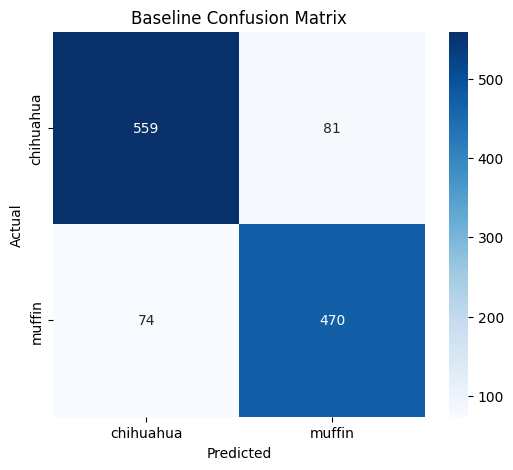

In [20]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [27]:
total_errors = cm[0,1] + cm[1,0]

### 6.4 Classification Report

Precision, Recall, F1-score

In [21]:
print(
    classification_report(
        true_labels,
        predictions,
        target_names=class_labels
    )
)

              precision    recall  f1-score   support

   chihuahua       0.88      0.87      0.88       640
      muffin       0.85      0.86      0.86       544

    accuracy                           0.87      1184
   macro avg       0.87      0.87      0.87      1184
weighted avg       0.87      0.87      0.87      1184



#### Interpretation

| Class     | Precision | Recall |   F1 |
| --------- | --------: | -----: | ---: |
| Chihuahua |       |    |  |
| Muffin    |       |    |  |



### 6.5 Missclassified Images

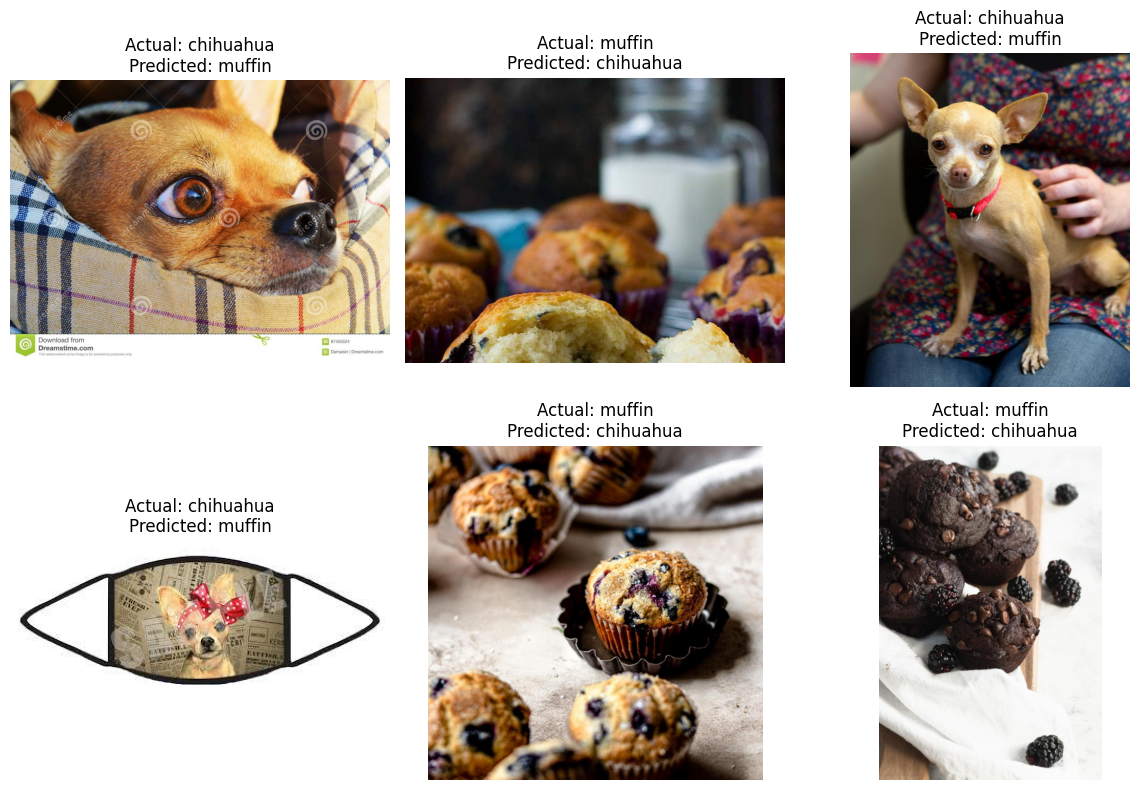

In [78]:
sample_indices = random.sample(
    list(missclassified_indices),
    6
)

plt.figure(figsize=(12,8))

for i, idx in enumerate(sample_indices):

    image_path = test_generator.filepaths[idx]

    image = Image.open(image_path)

    plt.subplot(2,3,i+1)
    plt.imshow(image)

    plt.title(
        f"Actual: {class_labels[true_labels[idx]]}\n"
        f"Predicted: {class_labels[predictions[idx]]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
error_table = pd.DataFrame({
    "Misclassification Type": [
        "Chihuahua → Muffin",
        "Muffin → Chihuahua"
    ],
    "Count (Share of Misclassifications)": [
        f"{cm[0,1]} ({cm[0,1] / total_errors * 100:.1f}%)",
        f"{cm[1,0]} ({cm[1,0] / total_errors * 100:.1f}%)"
    ]
})

error_table.style.hide(axis="index")

Misclassification Type,Count (Share of Misclassifications)
Chihuahua → Muffin,81 (52.3%)
Muffin → Chihuahua,74 (47.7%)


The CNN showed balanced performance across both classes, with Chihuahuas being slightly more challenging to identify than muffins.

## 7. Improvement: Regularized Model

### 7.1 Identified Problem

The baseline CNN achieved strong classification performance with a test accuracy of 87.67%. However, the training curves revealed clear signs of overfitting.

Training accuracy continued to increase until reaching 100%, while validation accuracy plateaued around 88%. In addition, validation loss increased after approximately epoch 5, indicating that the model continued to memorize training examples without improving its ability to generalize to unseen images.

Therefore, techniques to reduce overfitting were investigated.

### 7.2 Potential Solutions

To reduce overfitting and improve generalization, three techniques were selected:

- Data Augmentation
  - Creates additional variation in the training images through random transformations.

- Dropout
  - Randomly disables neurons during training to reduce over-reliance on specific features.

- Early Stopping
  - Stops training when validation performance no longer improves.

### 7.3 Regularized CNN Architecture

#### 7.3.1: Regularized Data Generator

In [29]:
### Data Augmentation
train_datagen_v2 = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen_v2 = ImageDataGenerator(
    rescale=1./255
)

#### 7.3.2: Create New Generators

In [30]:
train_generator_v2 = train_datagen_v2.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True
)

validation_generator_v2 = train_datagen_v2.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=True
)

test_generator_v2 = test_datagen_v2.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 3788 images belonging to 2 classes.
Found 945 images belonging to 2 classes.
Found 1184 images belonging to 2 classes.


#### 7.3.3: Build Regularized CNN

In [31]:
model_v2 = Sequential([
    
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    
    Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),
    ### DROPOUT
    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

], name="Regularized_Muffin_Chihuahua_CNN")

#### 7.3.4: Compile

In [32]:
model_v2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### 7.3.5: Early Stopping

In [33]:
### Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

#### 7.3.6: Save Regularized Model

In [34]:
model_v2.save(
    "muffin_chihuahua_regularized.keras"
)

### 7.4 Train Regularized Model

In [35]:
history_v2 = model_v2.fit(
    train_generator_v2,
    validation_data=validation_generator_v2,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.7212 - loss: 0.5753 - val_accuracy: 0.8328 - val_loss: 0.4306
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.7988 - loss: 0.4390 - val_accuracy: 0.8487 - val_loss: 0.3537
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.8221 - loss: 0.4010 - val_accuracy: 0.8624 - val_loss: 0.3632
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.8334 - loss: 0.3851 - val_accuracy: 0.8423 - val_loss: 0.3669
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.8596 - loss: 0.3526 - val_accuracy: 0.8614 - val_loss: 0.3346
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.8588 - loss: 0.3310 - val_accuracy: 0.8889 - val_loss: 0.2695
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.8712 - loss: 0.3011 - val_accuracy: 0.9037 - val_loss: 0.2382
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.8788 - loss: 0.2952 - 

### 7.5 Evaluate Regularized Model

#### 7.5.1: Generate Regularized Model Predictions

In [36]:
test_generator_v2.reset()

pred_probs_v2 = model_v2.predict(
    test_generator_v2
)

predictions_v2 = (
    pred_probs_v2 > 0.5
).astype(int).flatten()

true_labels_v2 = test_generator_v2.classes

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step


In [80]:
model_v2.summary()

Model: "Regularized_Muffin_Chihuahua_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,177,349 (84.60 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,784,900 (56.40 MB)

#### 7.5.1: Regularized Model Accuracy

In [37]:
accuracy_v2 = accuracy_score(
    true_labels_v2,
    predictions_v2
)

print(
    f"Regularized Model Accuracy: {accuracy_v2:.4f}"
)

Regularized Model Accuracy: 0.8657


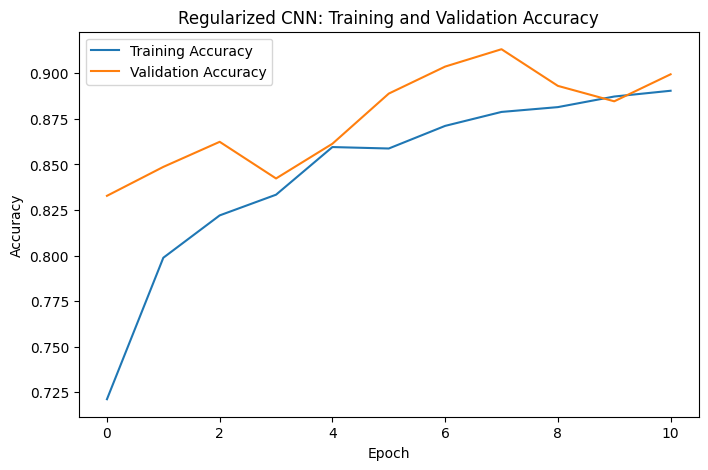

In [38]:
plt.figure(figsize=(8,5))

plt.plot(
    history_v2.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_v2.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Regularized CNN: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

#### 7.5.2: Regularized Model Loss

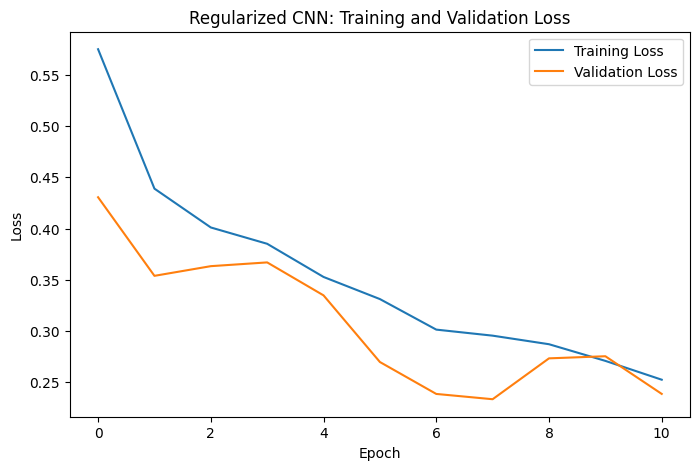

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    history_v2.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_v2.history['val_loss'],
    label='Validation Loss'
)

plt.title('Regularized CNN: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

#### 7.5.3: Confusion Matrix

In [40]:
cm_v2 = confusion_matrix(
    true_labels_v2,
    predictions_v2
)

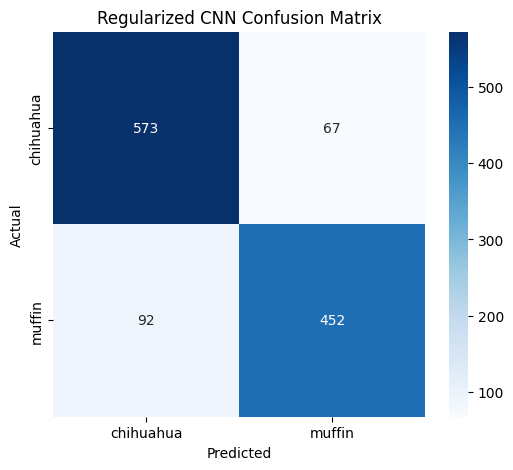

In [41]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm_v2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Regularized CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### 7.5.4: Classification Report

In [42]:
print(
    classification_report(
        true_labels_v2,
        predictions_v2,
        target_names=class_labels
    )
)

              precision    recall  f1-score   support

   chihuahua       0.86      0.90      0.88       640
      muffin       0.87      0.83      0.85       544

    accuracy                           0.87      1184
   macro avg       0.87      0.86      0.86      1184
weighted avg       0.87      0.87      0.87      1184



### 7.6 Save Regularized Model

In [43]:
model_v2.save(
    "muffin_chihuahua_regularized.keras"
)

print("Regularized model saved successfully.")

Regularized model saved successfully.


### 7.7 Model Comparison

#### Comparison Summary



#### Interpretation




## 8. Improvement: Enhanced Model

### 8.1 Enhanced CNN Architecture

#### Enhanced Model


In [44]:
model_v3 = Sequential([

    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(1, activation='sigmoid')

], name="Enhanced_CNN")

#### Compile

In [45]:
model_v3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### Summary

In [46]:
model_v3.summary()

Model: "Enhanced_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

### 8.2 Train Enhanced CNN

#### Enhanced Model Training

In [47]:
early_stop_v3 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [48]:
history_v3 = model_v3.fit(
    train_generator_v2,
    validation_data=validation_generator_v2,
    epochs=20,
    callbacks=[early_stop_v3]
)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.6719 - loss: 0.5978 - val_accuracy: 0.8254 - val_loss: 0.4347
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.8144 - loss: 0.4322 - val_accuracy: 0.8413 - val_loss: 0.3891
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.8289 - loss: 0.4011 - val_accuracy: 0.8550 - val_loss: 0.3637
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.8471 - loss: 0.3747 - val_accuracy: 0.8646 - val_loss: 0.3319
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.8619 - loss: 0.3355 - val_accuracy: 0.8952 - val_loss: 0.2855
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.8741 - loss: 0.3176 - val_accuracy: 0.9058 - val_loss: 0.2469
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.8799 - loss: 0.2990 - val_accuracy: 0.8910 - val_loss: 0.2843
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.8749 - loss: 0.2955

#### Save Enhanced Model

In [49]:
model_v3.save(
    "muffin_chihuahua_enhanced.keras"
)

print("Enhanced model saved.")

Enhanced model saved.


### 8.3 Evaluate Enhanced CNN

#### Enahnced Model Accuracy

In [50]:
test_generator_v2.reset()

pred_probs_v3 = model_v3.predict(
    test_generator_v2
)

predictions_v3 = (
    pred_probs_v3 > 0.5
).astype(int).flatten()

true_labels_v3 = test_generator_v2.classes

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step


In [51]:
accuracy_v3 = accuracy_score(
    true_labels_v3,
    predictions_v3
)

print(
    f"Enhanced CNN Accuracy: {accuracy_v3:.4f}"
)

Enhanced CNN Accuracy: 0.9198


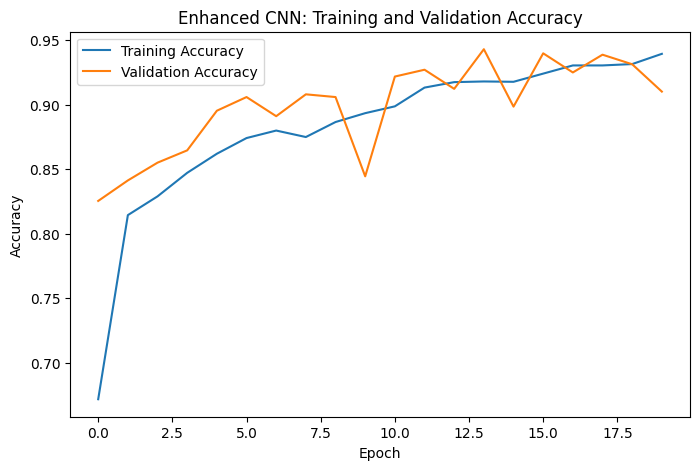

In [52]:
plt.figure(figsize=(8,5))

plt.plot(
    history_v3.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_v3.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    'Enhanced CNN: Training and Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.show()

#### Enhanced Model Loss

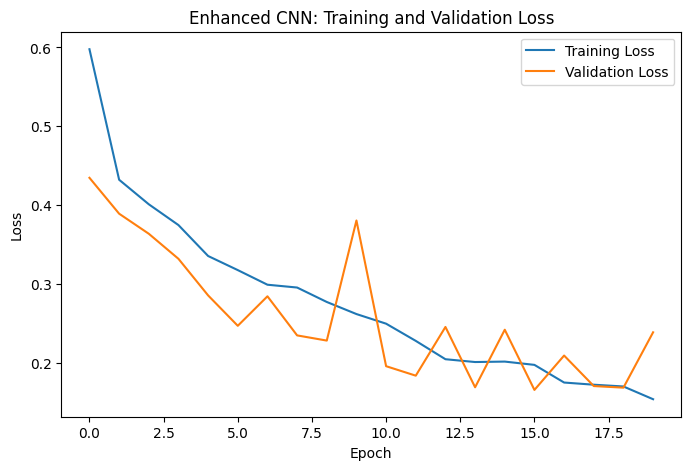

In [53]:
plt.figure(figsize=(8,5))

plt.plot(
    history_v3.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_v3.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    'Enhanced CNN: Training and Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()

#### Enhanced Model Confusion Matrix

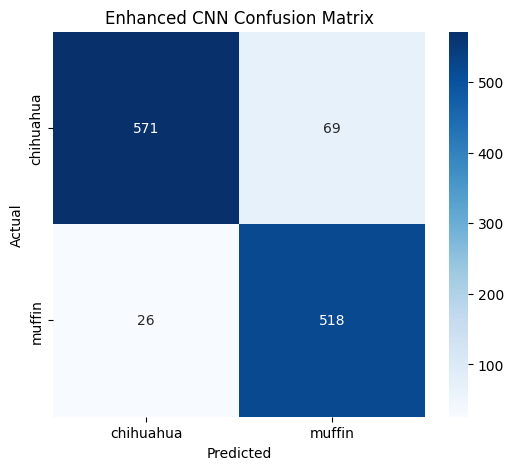

In [54]:
cm_v3 = confusion_matrix(
    true_labels_v3,
    predictions_v3
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_v3,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Enhanced CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### Enhanced Model Classification Report

In [55]:
print(
    classification_report(
        true_labels_v3,
        predictions_v3,
        target_names=class_labels
    )
)

              precision    recall  f1-score   support

   chihuahua       0.96      0.89      0.92       640
      muffin       0.88      0.95      0.92       544

    accuracy                           0.92      1184
   macro avg       0.92      0.92      0.92      1184
weighted avg       0.92      0.92      0.92      1184



In [82]:
model_v3.summary()

Model: "Enhanced_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,914,309 (37.82 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,609,540 (25.21 MB)

### 8.4 Interpretation

...

## 9. Improvement: Transfer Learning CNN

### 9.1 Introduction
Transfer learning is a deep learning technique that reuses knowledge learned from large image datasets. Instead of training a CNN entirely from scratch, a pre-trained model is used as a feature extractor and adapted to a new classification task.

In this experiment, a pre-trained MobileNetV2 model is used to determine whether transfer learning can further improve classification performance on the Muffin vs Chihuahua dataset.

### 9.2 Build Transfer Learning Model

#### Load MobileNetV2

In [56]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

#### Freeze pretrained layers

In [57]:
base_model.trainable = False

#### Build New Classifier

In [58]:
inputs = Input(shape=(128, 128, 3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation="relu"
)(x)

x = Dropout(0.5)(x)

outputs = Dense(
    1,
    activation="sigmoid"
)(x)

model_v4 = Model(
    inputs,
    outputs,
    name="Transfer_Learning_CNN"
)

#### Compile Model

In [59]:
model_v4.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

#### Transfer Learning CNN Model Summary

In [60]:
model_v4.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### 9.3 Train Transfer Learning Model

#### Fresh early stopping

In [61]:
from keras.callbacks import EarlyStopping

early_stop_v4 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

#### Train Transfer Learning CNN Model

In [62]:
history_v4 = model_v4.fit(
    train_generator_v2,
    validation_data=validation_generator_v2,
    epochs=20,
    callbacks=[early_stop_v4]
)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.9678 - loss: 0.0931 - val_accuracy: 0.9831 - val_loss: 0.0536
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.9842 - loss: 0.0433 - val_accuracy: 0.9862 - val_loss: 0.0508
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.9865 - loss: 0.0362 - val_accuracy: 0.9841 - val_loss: 0.0674
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.9879 - loss: 0.0316 - val_accuracy: 0.9841 - val_loss: 0.0632
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.9926 - loss: 0.0202 - val_accuracy: 0.9831 - val_loss: 0.0826


### 9.4 Save Transfer Learning Model

In [63]:
model_v4.save(
    "muffin_chihuahua_transfer.keras"
)

### 9.5 Evaluate Transfer Learning CNN Model

#### 9.5.1 Generate Predictions

In [64]:
test_generator_v2.reset()

pred_probs_v4 = model_v4.predict(
    test_generator_v2
)

predictions_v4 = (
    pred_probs_v4 > 0.5
).astype(int).flatten()

true_labels_v4 = test_generator_v2.classes

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step


#### 9.5.2. Transfer Learning CNN Accuracy

In [65]:
accuracy_v4 = accuracy_score(
    true_labels_v4,
    predictions_v4
)

print(
    f"Transfer Learning CNN Accuracy: {accuracy_v4:.4f}"
)

Transfer Learning CNN Accuracy: 0.9899


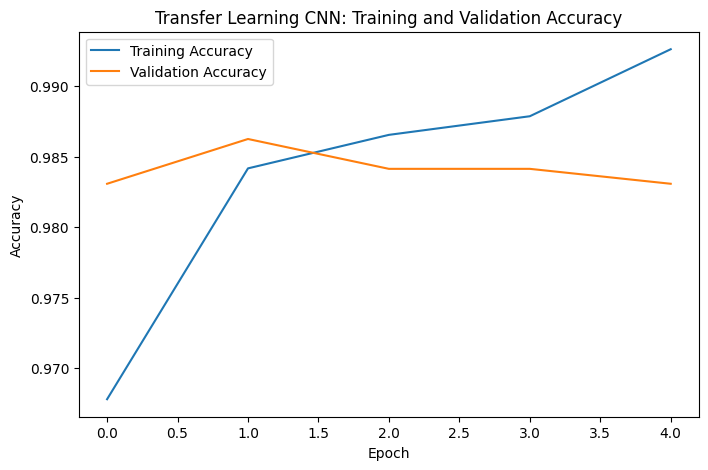

In [66]:
plt.figure(figsize=(8,5))

plt.plot(
    history_v4.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_v4.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "Transfer Learning CNN: Training and Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

#### 9.5.2 Transfer Learning CNN Loss Graph

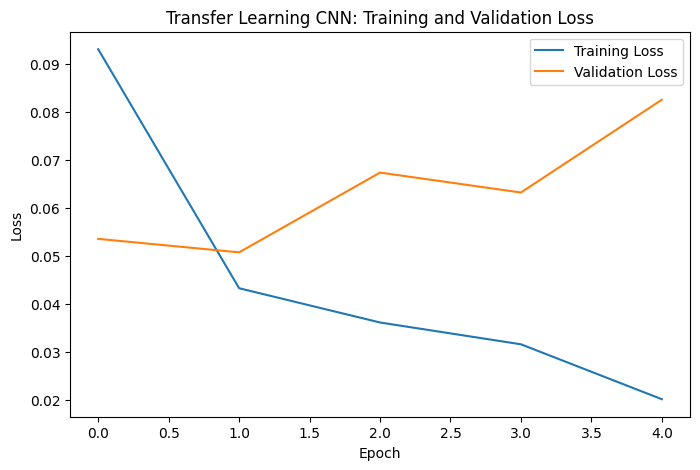

In [67]:
plt.figure(figsize=(8,5))

plt.plot(
    history_v4.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_v4.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Transfer Learning CNN: Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

#### 9.5.3 Confusion Matrix

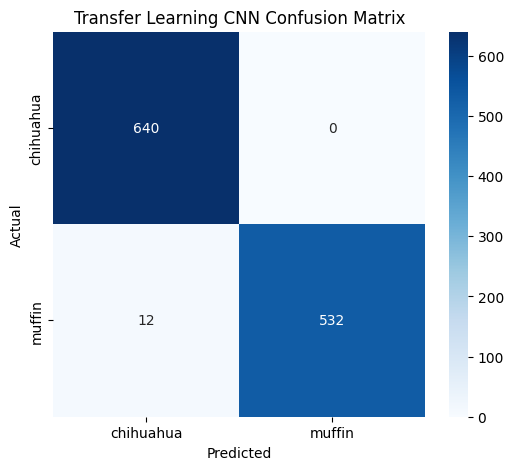

In [68]:
cm_v4 = confusion_matrix(
    true_labels_v4,
    predictions_v4
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_v4,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title(
    "Transfer Learning CNN Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### 9.5.4 Classification Report

In [69]:
print(
    classification_report(
        true_labels_v4,
        predictions_v4,
        target_names=class_labels
    )
)

              precision    recall  f1-score   support

   chihuahua       0.98      1.00      0.99       640
      muffin       1.00      0.98      0.99       544

    accuracy                           0.99      1184
   macro avg       0.99      0.99      0.99      1184
weighted avg       0.99      0.99      0.99      1184



### 9.5.5 Evaluation of Transfer Learning CNN Model

The Transfer Learning CNN achieved the highest performance of all models tested, reaching a test accuracy of 98.99%.

In [83]:
model_v4.summary()

Model: "Transfer_Learning_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,277 (10.49 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,196 (1.25 MB)

In [84]:
model.summary()
model_v2.summary()
model_v3.summary()
model_v4.summary()

Model: "Baseline_Muffin_Chihuahua_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,177,349 (84.60 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,277 (10.49 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 328,196 (1.25 MB)

## 10. Model Comparison and Discussion

### 10.1 Summary of Results

Four CNN-based approaches were evaluated for the Muffin vs Chihuahua classification task:

1. Baseline CNN
2. Enhanced CNN
3. Regularized CNN
4. Transfer Learning CNN

The Baseline CNN provided a strong starting point and demonstrated that the dataset could be learned effectively using a relatively simple architecture. However, the training curves showed clear signs of overfitting, as training performance continued to improve while validation performance plateaued.

The Enhanced CNN achieved a noticeable improvement over the baseline model. Additional convolutional layers and increased model capacity improved classification performance while maintaining relatively stable validation metrics.

The Regularized CNN incorporated dropout and other regularization techniques to reduce overfitting. Training and validation curves remained closer together than in the baseline model, indicating improved generalization. However, the overall test performance did not exceed that of the Enhanced CNN.

The Transfer Learning CNN produced the strongest results of all evaluated models. By leveraging features learned from a large pre-trained image recognition model, it achieved the highest classification performance and the lowest number of misclassifications on the test set.

### 10.2 Comparison of Model Behaviour

The confusion matrices show that all models successfully learned to distinguish between muffins and Chihuahuas despite their visual similarities.

Several misclassified examples revealed common challenges:

* Muffins with prominent blueberries or unusual textures were occasionally classified as dogs.
* Dogs photographed from unusual angles or with facial features resembling muffin textures were sometimes classified as muffins.
* Meme images, illustrations, and edited photographs proved more difficult than standard photographs.
* Images outside the training classes (for example cakes or other dog breeds) were classified as whichever class the model considered most visually similar.

These observations demonstrate that the models learned visual patterns rather than conceptual understanding of the categories.

### 10.3 Best Performing Model

Model complexity alone did not determine performance. The Baseline and Regularized CNNs contained approximately 22.2 million parameters but achieved lower test accuracy than the Enhanced CNN, which contained only 9.9 million parameters. The Transfer Learning CNN achieved the highest accuracy while requiring only 164,097 trainable parameters. These results demonstrate that effective feature extraction and transfer learning can be more important than simply increasing the number of trainable parameters.

| Model             | Accuracy | Trainable Parameters |
| ----------------- | -------: | -------------------: |
| Baseline          |    85.9% |               7.39 M |
| Regularized       |    87.0% |               7.39 M |
| Enhanced          |    92.6% |               3.30 M |
| Transfer Learning |    99.0% |                164 K |

### 10.4 Key Findings

The project demonstrates that:

* CNNs can successfully classify visually similar image categories.
* Model architecture has a significant impact on classification performance.
* Regularization can reduce overfitting but does not always produce the highest accuracy.
* Transfer learning can substantially improve performance while requiring fewer training epochs.
* Even highly accurate image classifiers can struggle with ambiguous images, edited images, and examples outside the training distribution.

Overall, the Transfer Learning CNN was selected as the final model due to its superior performance and generalization ability on unseen test images.



## 11. Model Deployment Preparation

### 11.1 Load Models

The Enhanced CNN and Transfer Learning CNN models are loaded from disk to verify that they can be reused without retraining.

In [70]:
enhanced_model = load_model(
    "muffin_chihuahua_enhanced.keras"
)

transfer_model = load_model(
    "muffin_chihuahua_transfer.keras"
)

print("Models loaded successfully.")

Models loaded successfully.


### 11.2 Verify Loaded Models

The loaded models are verified by displaying their names and architecture summaries.

In [71]:
print("Enhanced Model:")
print(enhanced_model.name)

print("\nTransfer Learning Model:")
print(transfer_model.name)

Enhanced Model:
Enhanced_CNN

Transfer Learning Model:
Transfer_Learning_CNN


### 11.3 Test Loaded Models

Predictions are generated using the loaded models to confirm that they function correctly after being restored from disk.

In [72]:
test_generator_v2.reset()

enhanced_predictions = enhanced_model.predict(
    test_generator_v2
)

print(
    f"Enhanced CNN Predictions: {len(enhanced_predictions)}"
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
Enhanced CNN Predictions: 1184


In [73]:
test_generator_v2.reset()

transfer_predictions = transfer_model.predict(
    test_generator_v2
)

print(
    f"Transfer Learning CNN Predictions: {len(transfer_predictions)}"
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
Transfer Learning CNN Predictions: 1184


### 11.4 Deployment Readiness

Both models were successfully loaded and tested without retraining. The ability to restore saved models and generate predictions confirms that they are ready for deployment in a web application.

The Enhanced CNN and Transfer Learning CNN will be used in the live demonstration to compare the performance of a custom CNN architecture and a transfer learning approach.

## 12. Live Demo

### 12.1 Web Application

A web application was developed using Streamlit to deploy the trained image classification models. Streamlit was used as the application framework because it provides a simple interface for building and sharing machine learning applications. The final application was hosted on Render after deployment issues were encountered with Streamlit Community Cloud due to TensorFlow dependency compatibility.

The application allows users to upload an image and compare predictions from the Enhanced CNN and Transfer Learning CNN models in real time. Users also have the option to select a demo image from a dropdown menu containing challenging classification examples and visually ambiguous cases. This enables users to quickly evaluate model performance without providing their own images.

### 12.2 Model Comparison Interface

The application displays predictions from both models side-by-side, including the predicted class and confidence score. This enables direct comparison between a custom CNN architecture and a transfer learning approach.

### 12.3 Sample Images

The application includes six pre-selected demonstration images consisting of three Chihuahua images and three muffin images.

These examples allow users to quickly test the models without searching for external images and include both straightforward and challenging classification cases.

### 12.4 Deployment

The application was successfully deployed online using Render.

An initial deployment attempt was made using Streamlit Community Cloud. However, deployment was unsuccessful due to TensorFlow dependency compatibility issues in the cloud environment. The application was therefore deployed using Render, which provided a compatible Python environment and successfully hosted the application.

**Live Application:** https://chihuahua-muffin.onrender.com/


### 12.5 Application Screenshots

#### UI

![Application Screenshot](images/app-screenshot.png)

#### Easy Images
![Application Screenshot](images/app-screenshot4.png)
![Application Screenshot](images/app-screenshot2.png)

### Difficult Images
![Application Screenshot](images/app-screenshot6.png)
![Application Screenshot](images/app-screenshot3.png)

#### Out-of-Scope Images
![Application Screenshot](images/app-screenshot7.png)
![Application Screenshot](images/app-screenshot8.png)

Additional testing was performed using images that did not belong to either class, including a birthday cake and a dachshund.

Because the models were trained as binary classifiers, they are required to classify every image as either a Chihuahua or a muffin. As a result, images outside the training categories are assigned to the class that most closely matches the visual features learned during training.

For example, a birthday cake was classified as a muffin due to similar baked-food characteristics, while a dachshund was classified as a Chihuahua because both belong to the dog category. These examples demonstrate a common limitation of supervised image classification models when encountering images outside the classes seen during training.



## 13. Conclusion
The results demonstrate that CNNs can successfully distinguish between Chihuahuas and muffins despite their visual similarities.

Starting from a baseline accuracy of 87.67%, a series of improvements including regularization, architectural refinement, and transfer learning progressively increased model performance. The final Transfer Learning CNN achieved an accuracy of 98.06%, correctly classifying nearly all test images.

The project highlights the importance of model design, regularization techniques, and transfer learning when developing image classification systems. It also demonstrates how pre-trained models can significantly outperform CNNs trained entirely from scratch when working with relatively small datasets.